# Synthetic Noisy CIFAR Dataset Generator

## CS506 Anomaly Detection Project
### Data sources: 
  - CIFAR-10/100: https://www.cs.toronto.edu/~kriz/cifar.html
  - CIFAR-10-100-N: https://github.com/UCSC-REAL/cifar-10-100n
  - MIT Scene Dataset: https://web.mit.edu/torralba/www/indoor.html 
### 9 Anomaly Types:

| Type | % | Description |
|------|---|-------------|
| **Clean** | 35% | Correctly labeled |
| **Near-Miss** | 15% | ViT-based similar class |
| **Gross** | 10% | ViT-based distant class |
| **OOD** | 5% | MIT Indoor Scenes |
| **Clean-Hard** | 15% | ViT centroid distance |
| **Random Flip** | 10% | Random label |
| **Ambiguous** | 5% | CIFAR-N disagreements |
| **Corrupted** | 5% | Image corruptions |

---

In [1]:
import os, pickle, numpy as np, random, json, csv, time
from pathlib import Path
from typing import Dict, List, Tuple
from PIL import Image
from collections import Counter
from scipy.ndimage import gaussian_filter
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt
import pandas as pd
import timm
import torch
import torch.nn as nn
from torchvision import transforms

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.cuda.empty_cache()

# Paths
CIFAR10_DATA_PATH = Path("/projectnb/ivc-ml/appledora/CS506/cs506-anomaly-det/data/cifar-10-batches-py")
CIFAR100_DATA_PATH = Path("/projectnb/ivc-ml/appledora/CS506/cs506-anomaly-det/data/cifar-100-python")
CIFAR10N_PATH = Path("/projectnb/ivc-ml/appledora/CS506/cifar-10-100n/data/CIFAR-10_human_ordered.npy")
CIFAR100N_PATH = Path("/projectnb/ivc-ml/appledora/CS506/cifar-10-100n/data/CIFAR-100_human_ordered.npy")
MIT_SCENES_PATH = Path("/net/ivcfs5/mnt/data/nimzia/datasets_typo/MIT-scenes")
OUTPUT_DIR = Path("/projectnb/ivc-ml/appledora/CS506/cs506-anomaly-det/data_vit_base")
CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
CIFAR100_CLASSES = ['apple','aquarium_fish','baby','bear','beaver','bed','bee','beetle','bicycle','bottle','bowl','boy','bridge','bus','butterfly','camel','can','castle','caterpillar','cattle','chair','chimpanzee','clock','cloud','cockroach','couch','crab','crocodile','cup','dinosaur','dolphin','elephant','flatfish','forest','fox','girl','hamster','house','kangaroo','keyboard','lamp','l_mower','leopard','lion','lizard','lobster','man','maple_tree','motorcycle','mountain','mouse','mushroom','oak_tree','orange','orchid','otter','palm_tree','pear','pickup_truck','pine_tree','plain','plate','poppy','porcupine','possum','rabbit','raccoon','ray','road','rocket','rose','sea','seal','shark','shrew','skunk','skyscraper','snail','snake','spider','squirrel','streetcar','sunflower','sweet_pepper','table','tank','telephone','television','tiger','tractor','train','trout','tulip','turtle','wardrobe','whale','willow_tree','wolf','woman','worm']
CORRUPTION_TYPES = ['gaussian_noise', 'blur', 'contrast_low', 'brightness_low']
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Anomaly ratios
ANOMALY_RATIOS = {
    'clean': 0.35, 'near_miss': 0.15, 'gross': 0.10, 'ood': 0.05,
    'clean_hard': 0.15, 'random_flip': 0.10, 'ambiguous': 0.05, 'corrupted': 0.05,
}

# Colors for visualizations
ANOMALY_COLORS = {
    'clean': '#2ecc71', 'near_miss': '#3498db', 'gross': '#e74c3c', 'ood': '#9b59b6',
    'clean_hard': '#f39c12', 'random_flip': '#1abc9c', 'ambiguous': '#e67e22', 'corrupted': '#95a5a6',
}

VIT_MODEL_NAME = 'vit_base_patch16_224'
FEATURE_DIM = 768

vit_model = timm.create_model(VIT_MODEL_NAME, pretrained=True, num_classes=0).to(device)
vit_model.eval()

vit_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])



Using device: cuda


## ViT Utils

In [2]:
@torch.no_grad()
def extract_vit_features(images, batch_size=256, verbose=True):
    num_images = len(images)
    features = []
    
    if verbose:
        print(f"Extracting features for {num_images:,} images...")
        start = time.time()
    
    for i in range(0, num_images, batch_size):
        batch_images = images[i:min(i+batch_size, num_images)]
        batch_tensors = [vit_transform(img_flat.reshape(3,32,32).transpose(1,2,0) if img_flat.ndim==1 else img_flat) for img_flat in batch_images]
        batch_tensor = torch.stack(batch_tensors).to(device, non_blocking=True)
        features.append(vit_model(batch_tensor).cpu().numpy())
    
    features = np.vstack(features)
    if verbose:
        print(f"Done: {features.shape} in {time.time()-start:.1f}s")
    return features


def compute_vit_centroids(features, labels, num_classes):
    return {c: np.mean(features[labels==c], axis=0) for c in range(num_classes)}


def find_k_nearest(query, centroids, k=3, exclude=None):
    sims = {c: 1-cosine(query, cent) for c, cent in centroids.items() if c!=exclude}
    return [c for c,_ in sorted(sims.items(), key=lambda x:x[1], reverse=True)[:k]]


def find_k_furthest(query, centroids, k=3, exclude=None):
    sims = {c: 1-cosine(query, cent) for c, cent in centroids.items() if c!=exclude}
    return [c for c,_ in sorted(sims.items(), key=lambda x:x[1])[:k]]


def identify_hard_samples_vit(features, labels, centroids, ratio=0.15):
    dists = [(i, cosine(features[i], centroids[labels[i]])) for i in range(len(features))]
    dists.sort(key=lambda x:x[1], reverse=True)
    return set(x[0] for x in dists[:int(len(features)*ratio)])


def apply_corruption(img_flat, ctype):
    img = img_flat.reshape(3,32,32).transpose(1,2,0).astype(np.float32)
    if ctype=='gaussian_noise': img = img + np.random.normal(0,25,img.shape)
    elif ctype=='blur': img = gaussian_filter(img, sigma=1.5)
    elif ctype=='contrast_low': img = (img-img.mean())*0.3+img.mean()
    elif ctype=='brightness_low': img = img*0.3
    return np.clip(img,0,255).astype(np.uint8).transpose(2,0,1).flatten()



## Load Data

In [3]:
def load_cifar10(path):
    imgs, lbls, fnames = [], [], []
    for i in range(1,6):
        with open(path/f"data_batch_{i}",'rb') as f:
            b = pickle.load(f, encoding='bytes')
            imgs.append(b[b'data'])
            lbls.extend(b[b'labels'])
            fnames.extend([fn.decode() for fn in b[b'filenames']])
    return np.vstack(imgs), np.array(lbls), fnames

def load_cifar100(path):
    with open(path/"train",'rb') as f:
        d = pickle.load(f, encoding='bytes')
    return np.array(d[b'data']), np.array(d[b'fine_labels']), np.array(d[b'coarse_labels']), [fn.decode() for fn in d[b'filenames']]

def load_mit_scenes(path, max_per_cat=30):
    scenes = []
    for cat_dir in path.iterdir():
        if cat_dir.is_dir():
            for img_f in list(cat_dir.glob("*.jpg"))[:max_per_cat]:
                try:
                    img = Image.open(img_f).convert('RGB').resize((32,32))
                    scenes.append((np.array(img).transpose(2,0,1).flatten(), cat_dir.name))
                except: pass
    return scenes

print("Loading data...")
cifar10_imgs, cifar10_lbls, cifar10_fnames = load_cifar10(CIFAR10_DATA_PATH)
cifar100_imgs, cifar100_fine, cifar100_coarse, cifar100_fnames = load_cifar100(CIFAR100_DATA_PATH)
cifar10n = np.load(CIFAR10N_PATH, allow_pickle=True).item()
cifar100n = np.load(CIFAR100N_PATH, allow_pickle=True).item()
mit_scenes = load_mit_scenes(MIT_SCENES_PATH)

print(f"CIFAR-10: {len(cifar10_imgs):,}")
print(f"CIFAR-100: {len(cifar100_imgs):,}")
print(f"MIT Scenes: {len(mit_scenes):,} from {len(set(c for _,c in mit_scenes))} categories")

Loading data...


/scratch/4437793.1.ivcbuyin/ipykernel_652073/2843414038.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  b = pickle.load(f, encoding='bytes')
/scratch/4437793.1.ivcbuyin/ipykernel_652073/2843414038.py:13: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding='bytes')


CIFAR-10: 50,000
CIFAR-100: 50,000
MIT Scenes: 2,010 from 67 categories


In [4]:
cifar10_vit = extract_vit_features(cifar10_imgs)
if torch.cuda.is_available(): torch.cuda.empty_cache()
cifar100_vit = extract_vit_features(cifar100_imgs)

cifar10_cent = compute_vit_centroids(cifar10_vit, cifar10_lbls, 10)
cifar100_cent = compute_vit_centroids(cifar100_vit, cifar100_fine, 100)

cifar10_hard = identify_hard_samples_vit(cifar10_vit, cifar10_lbls, cifar10_cent)
cifar100_hard = identify_hard_samples_vit(cifar100_vit, cifar100_fine, cifar100_cent)

print(f"Features: CIFAR-10 {cifar10_vit.shape}, CIFAR-100 {cifar100_vit.shape}")

Extracting features for 50,000 images...
Done: (50000, 768) in 37.1s
Extracting features for 50,000 images...
Done: (50000, 768) in 35.9s
Features: CIFAR-10 (50000, 768), CIFAR-100 (50000, 768)


## Generate Dataset

In [5]:
def generate_vit_dataset(imgs, vit_feats, lbls, fnames, cifarN, vit_cent, num_cls, name, cls_names, mit_scenes, hard_idx):
    n = len(lbls)
    counts = {k:int(v*n) for k,v in ANOMALY_RATIOS.items()}
    if sum(counts.values())<n: counts['clean']+=n-sum(counts.values())
    
    indices = np.arange(n); np.random.shuffle(indices)
    assignments = {}
    start = 0
    for at,c in counts.items():
        assignments[at] = indices[start:start+c]
        start += c
    
    human_lbls = cifarN.get('aggre_label' if name=='cifar10' else 'noise_label', np.zeros(n)) if cifarN else None
    
    rows, ood_cats, corr_types, ambig_count, vit_nm, vit_gr = [], [], [], 0, 0, 0
    
    for at, idxs in assignments.items():
        for idx in idxs:
            orig_lbl = int(lbls[idx])
            feat = vit_feats[idx]
            h_lbl = int(human_lbls[idx]) if human_lbls is not None else ''
            h_avail = human_lbls is not None
            
            if at=='clean': synth_lbl = orig_lbl
            elif at=='near_miss':
                synth_lbl = random.choice(find_k_nearest(feat, vit_cent, k=3, exclude=orig_lbl))
                vit_nm += 1
            elif at=='gross':
                synth_lbl = random.choice(find_k_furthest(feat, vit_cent, k=3, exclude=orig_lbl))
                vit_gr += 1
            elif at=='ood':
                ood_img, ood_cat = random.choice(mit_scenes)
                ood_cats.append(ood_cat)
                synth_lbl = random.randint(0, num_cls-1)
            elif at=='clean_hard': synth_lbl = orig_lbl
            elif at=='random_flip': synth_lbl = random.choice([c for c in range(num_cls) if c!=orig_lbl])
            elif at=='ambiguous':
                if h_avail and h_lbl!=orig_lbl:
                    synth_lbl = h_lbl
                    ambig_count += 1
                else:
                    synth_lbl = random.choice(find_k_nearest(feat, vit_cent, k=3, exclude=orig_lbl))
            elif at=='corrupted': synth_lbl = orig_lbl
            else: synth_lbl = orig_lbl
            
            ctype = random.choice(CORRUPTION_TYPES) if at=='corrupted' else ''
            if ctype: corr_types.append(ctype)
            
            rows.append({
                'sample_index': int(idx), 'filename': fnames[idx],
                'original_label': orig_lbl, 'original_class_name': cls_names[orig_lbl],
                'synthetic_label': synth_lbl, 'synthetic_class_name': cls_names[synth_lbl],
                'anomaly_type': at, 'human_label': h_lbl if h_lbl!='' else '',
                'human_class_name': cls_names[h_lbl] if h_lbl!='' else '',
                'human_label_available': h_avail, 'ood_category': ood_cat if at=='ood' else '',
                'corruption_type': ctype, 'is_hard_sample': idx in hard_idx,
                'is_vit_based': at in ['near_miss','gross','clean_hard']
            })
    
    rows.sort(key=lambda x: x['sample_index'])
    print(f"Generated {len(rows):,} samples")
    print(f"ViT near-miss: {vit_nm}, gross: {vit_gr}")
    if ood_cats: print(f"OOD categories: {len(set(ood_cats))}")
    if corr_types: print(f"Corruptions: {Counter(corr_types)}")
    if ambig_count: print(f"Ambiguous: {ambig_count}")
    return rows

cifar10_rows = generate_vit_dataset(cifar10_imgs, cifar10_vit, cifar10_lbls, cifar10_fnames, cifar10n, cifar10_cent, 10, 'cifar10', CIFAR10_CLASSES, mit_scenes, cifar10_hard)
cifar100_rows = generate_vit_dataset(cifar100_imgs, cifar100_vit, cifar100_fine, cifar100_fnames, cifar100n, cifar100_cent, 100, 'cifar100', CIFAR100_CLASSES, mit_scenes, cifar100_hard)
# Create pandas DataFrames for visualization cells
df10 = pd.DataFrame(cifar10_rows)
df100 = pd.DataFrame(cifar100_rows)

Generated 50,000 samples
ViT near-miss: 7500, gross: 5000
OOD categories: 67
Corruptions: Counter({'blur': 650, 'gaussian_noise': 629, 'contrast_low': 613, 'brightness_low': 608})
Ambiguous: 2247
Generated 50,000 samples
ViT near-miss: 7500, gross: 5000
OOD categories: 67
Corruptions: Counter({'blur': 645, 'brightness_low': 631, 'contrast_low': 621, 'gaussian_noise': 603})
Ambiguous: 2466


## Visualizations

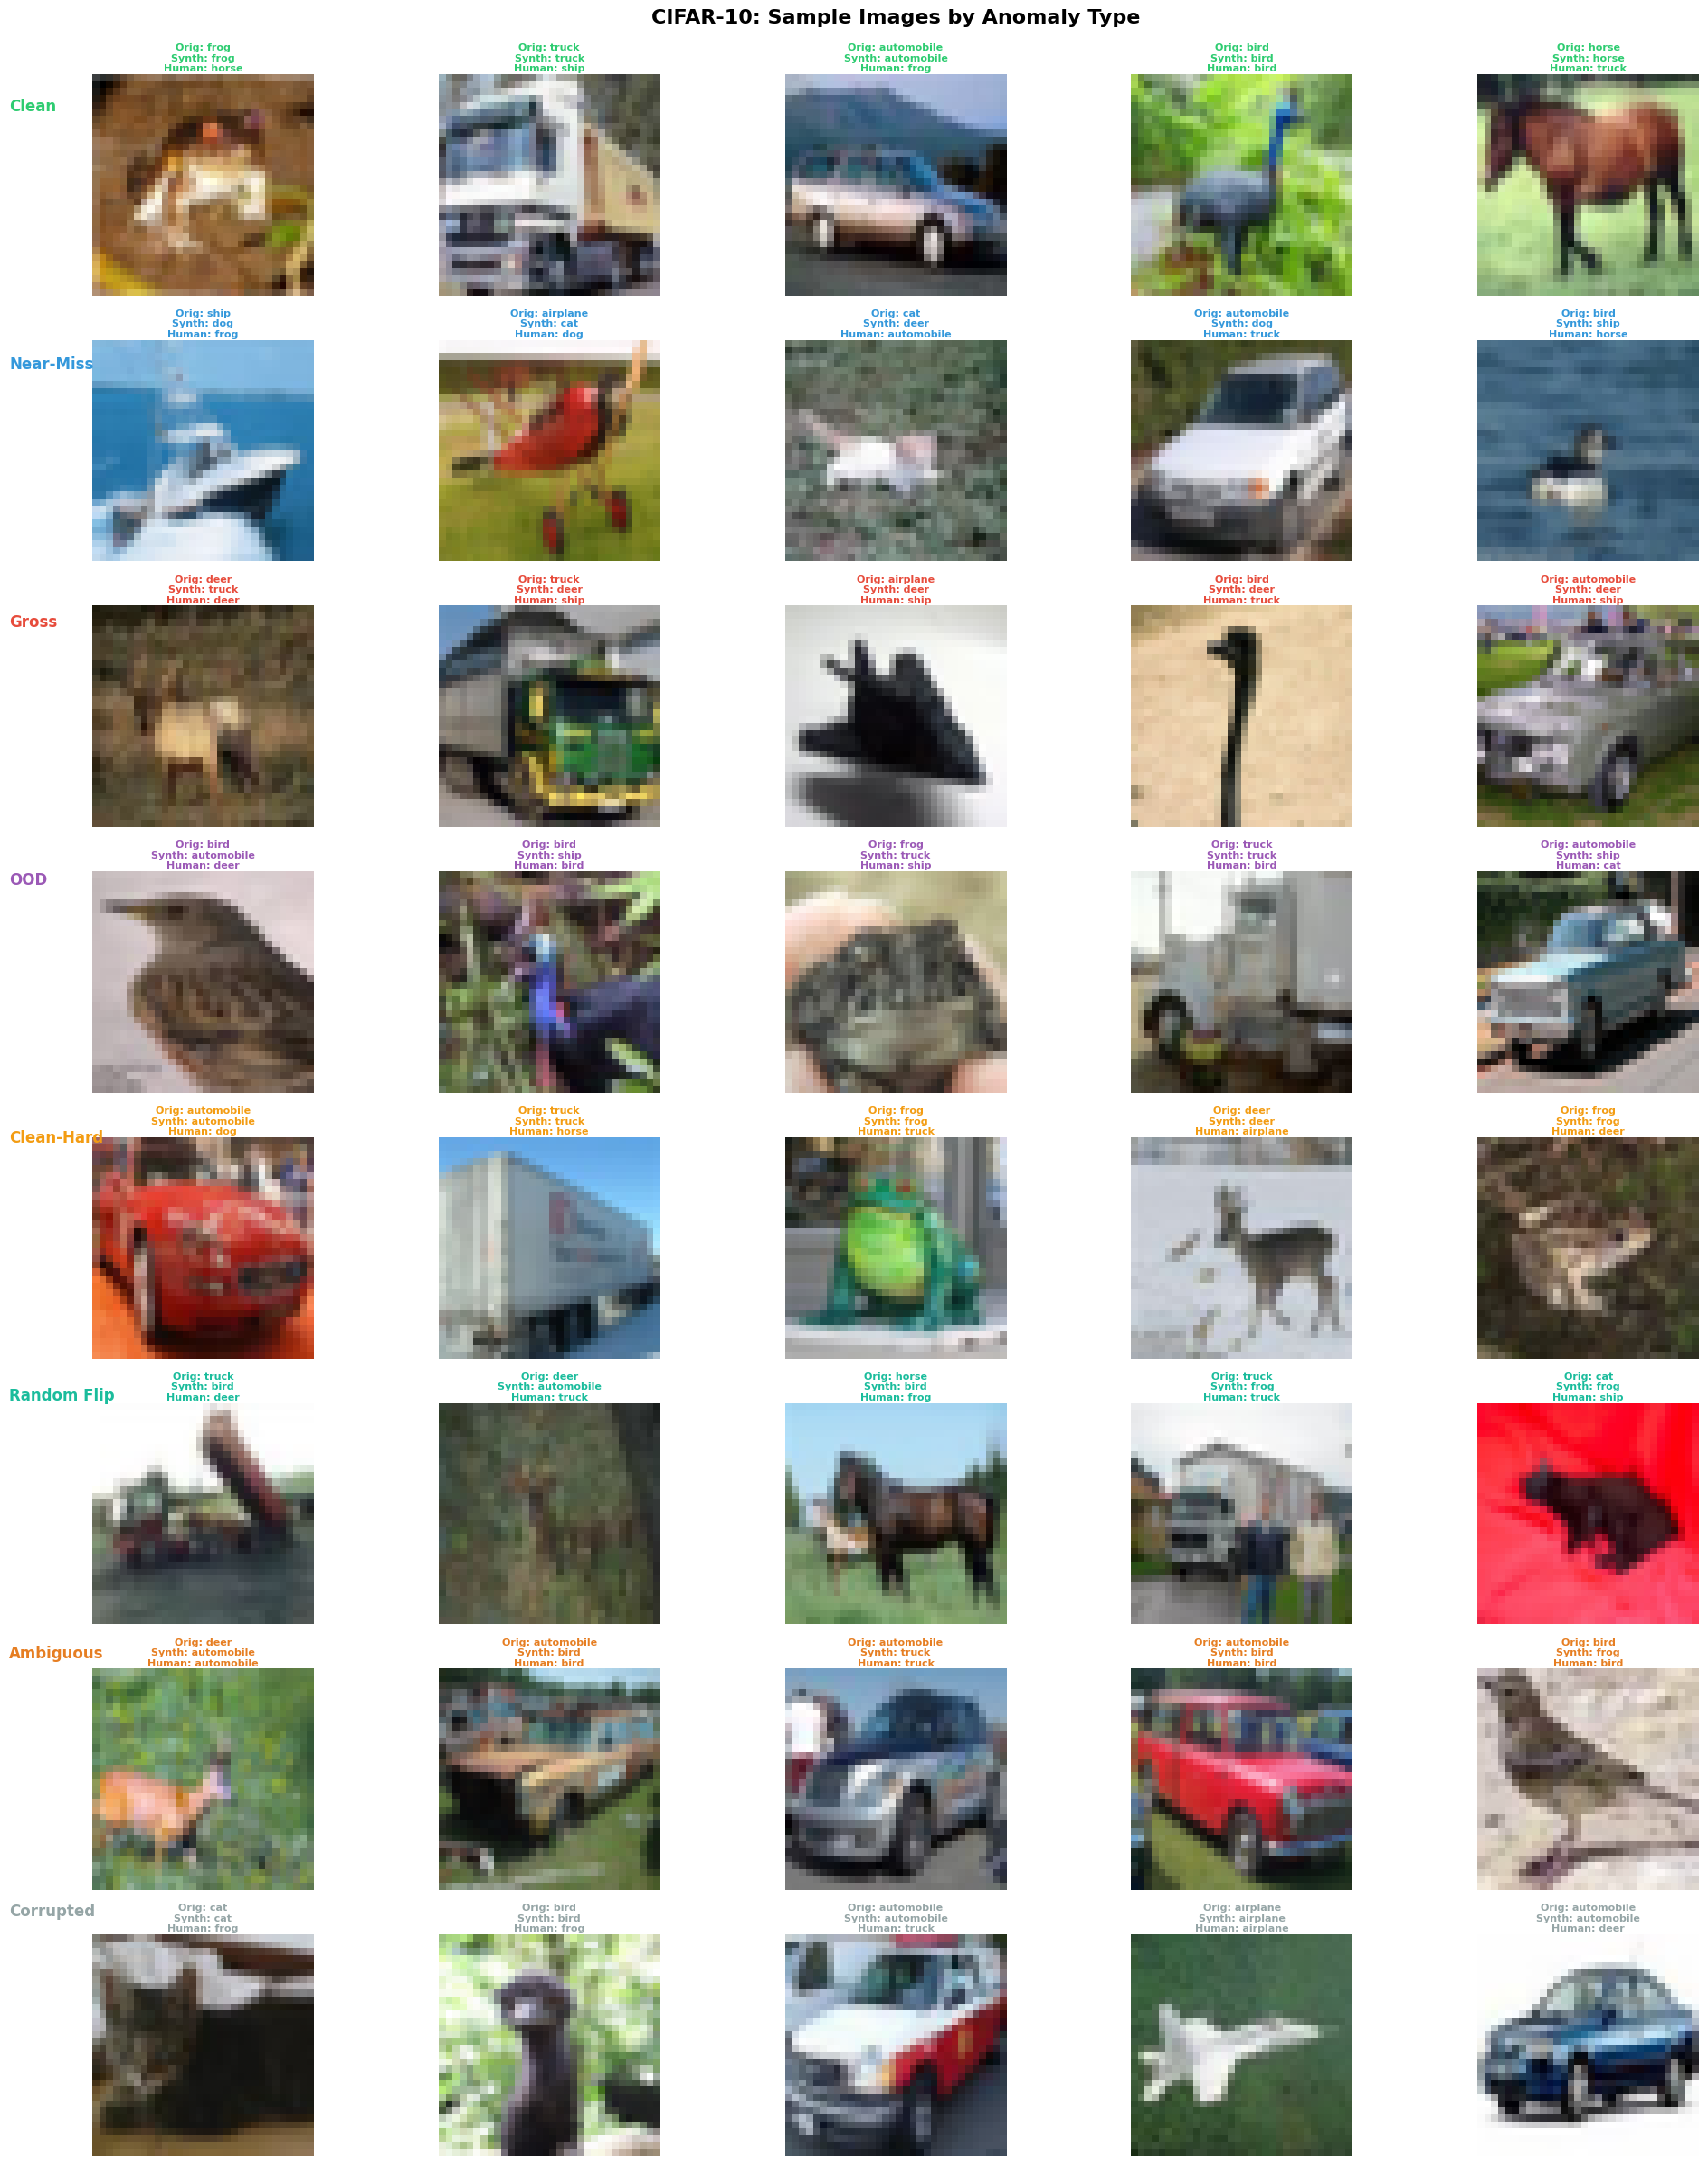

Saved: cifar10_samples_by_type.png


In [6]:
# Reshape images for visualization
cifar10_viz = cifar10_imgs.reshape(-1,3,32,32).transpose(0,2,3,1)

def plot_samples_by_type(df, imgs, name='CIFAR-10', n=5):
    types = ['clean','near_miss','gross','ood','clean_hard','random_flip','ambiguous','corrupted']
    fig, axes = plt.subplots(len(types), n, figsize=(20, 3*len(types)))
    fig.suptitle(f'{name}: Sample Images by Anomaly Type', fontsize=16, fontweight='bold', y=0.995)
    
    for ri, at in enumerate(types):
        samples = df[df['anomaly_type']==at].head(n)
        for ci, (_, s) in enumerate(samples.iterrows()):
            ax = axes[ri, ci]
            ax.imshow(imgs[s['sample_index']])
            ax.axis('off')
            tc = ANOMALY_COLORS[at]
            human = s['human_class_name'] if s['human_label_available'] and s['human_class_name'] else 'N/A'
            ax.set_title(f"Orig: {s['original_class_name']}\nSynth: {s['synthetic_class_name']}\nHuman: {human}",
                        fontsize=8, color=tc, fontweight='bold', pad=2)
            for sp in ax.spines.values(): sp.set_edgecolor(tc); sp.set_linewidth(2.5)
    
    for ri, lbl in enumerate(['Clean','Near-Miss','Gross','OOD','Clean-Hard','Random Flip','Ambiguous','Corrupted']):
        fig.text(0.01, 0.95-ri*(0.95/len(types)), lbl, fontsize=12, fontweight='bold',
                color=ANOMALY_COLORS[types[ri]], va='center', ha='left')
    
    plt.tight_layout()
    path = OUTPUT_DIR/f'{name.lower().replace("-","")}_samples_by_type.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path.name}')

plot_samples_by_type(df10, cifar10_viz, 'CIFAR-10', n=5)

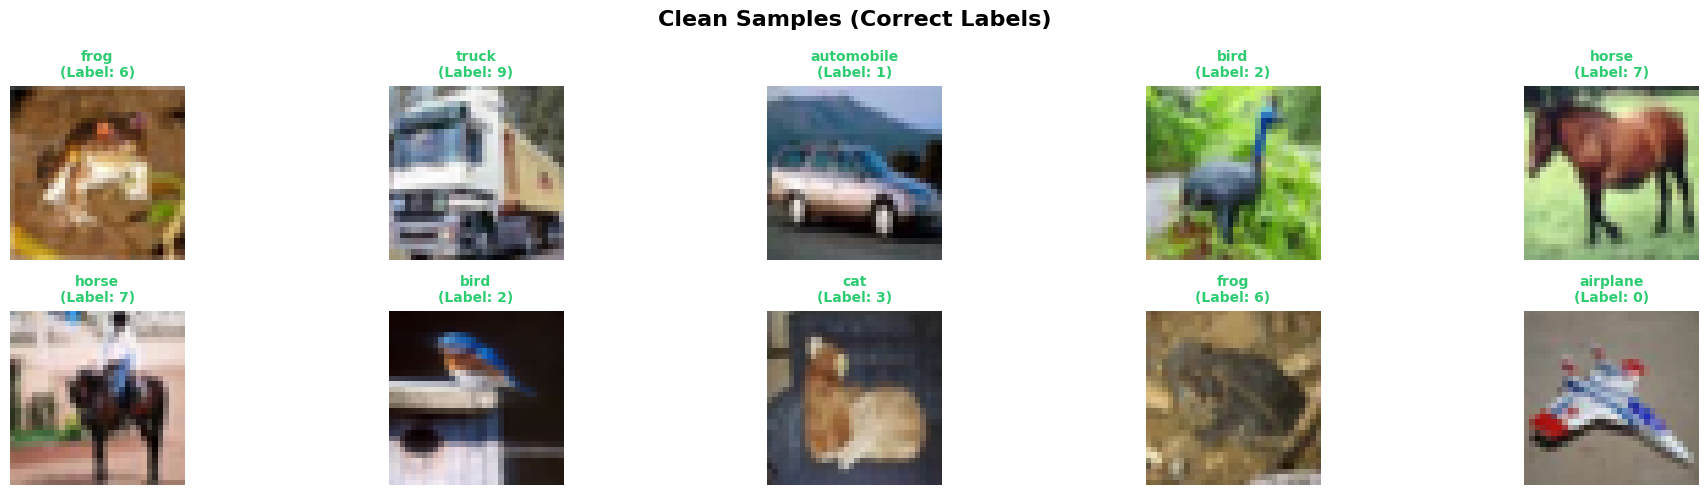

Saved: clean_samples.png


In [7]:
def plot_clean_samples(df, imgs, n=10):
    clean = df[df['anomaly_type']=='clean'].head(n)
    fig, axes = plt.subplots(2, n//2, figsize=(20, 5))
    fig.suptitle('Clean Samples (Correct Labels)', fontsize=16, fontweight='bold')
    
    for i, (_, s) in enumerate(clean.iterrows()):
        ax = axes[i//5, i%5]
        ax.imshow(imgs[s['sample_index']])
        ax.axis('off')
        ax.set_title(f"{s['original_class_name']}\n(Label: {s['original_label']})", fontsize=10, fontweight='bold', color='#2ecc71')
        for sp in ax.spines.values(): sp.set_edgecolor('#2ecc71'); sp.set_linewidth(2.5)
    
    plt.tight_layout()
    path = OUTPUT_DIR/'clean_samples.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path.name}')

plot_clean_samples(df10, cifar10_viz, n=10)

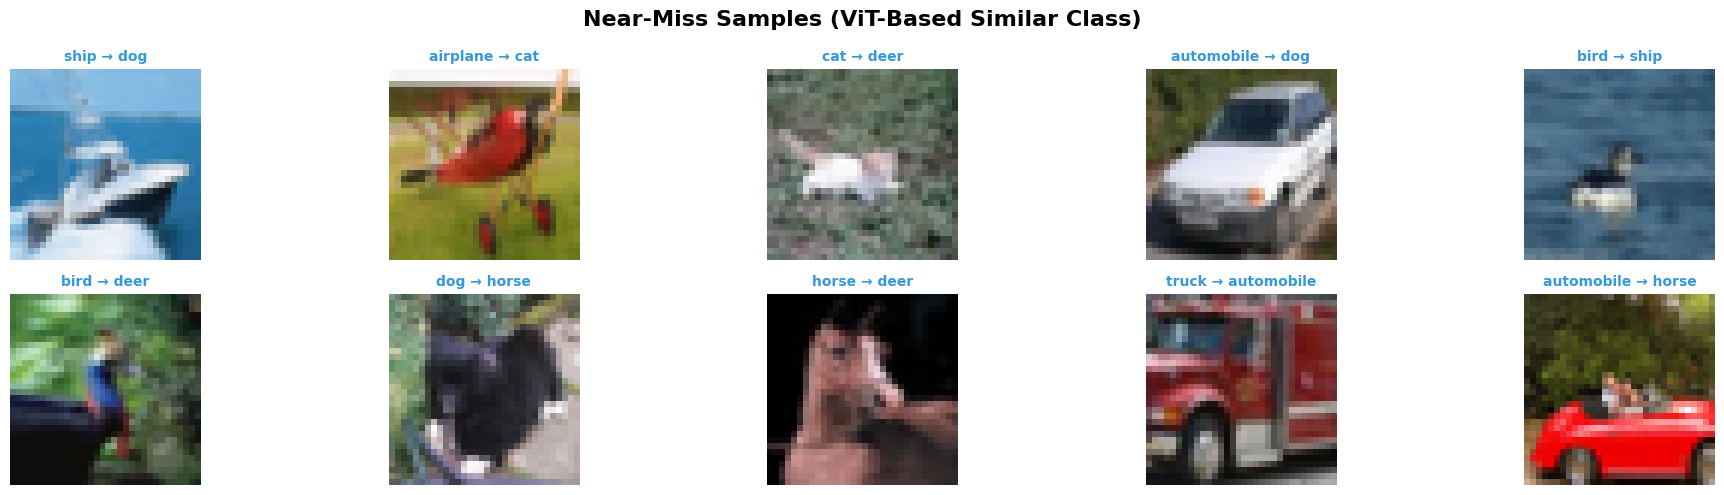

Saved: near_miss_samples.png


In [8]:
def plot_near_miss_samples(df, imgs, n=10):
    nm = df[df['anomaly_type']=='near_miss'].head(n)
    fig, axes = plt.subplots(2, n//2, figsize=(20, 5))
    fig.suptitle('Near-Miss Samples (ViT-Based Similar Class)', fontsize=16, fontweight='bold')
    
    for i, (_, s) in enumerate(nm.iterrows()):
        ax = axes[i//5, i%5]
        ax.imshow(imgs[s['sample_index']])
        ax.axis('off')
        ax.set_title(f"{s['original_class_name']} → {s['synthetic_class_name']}", fontsize=10, fontweight='bold', color='#3498db')
        for sp in ax.spines.values(): sp.set_edgecolor('#3498db'); sp.set_linewidth(2.5)
    
    plt.tight_layout()
    path = OUTPUT_DIR/'near_miss_samples.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path.name}')

plot_near_miss_samples(df10, cifar10_viz, n=10)

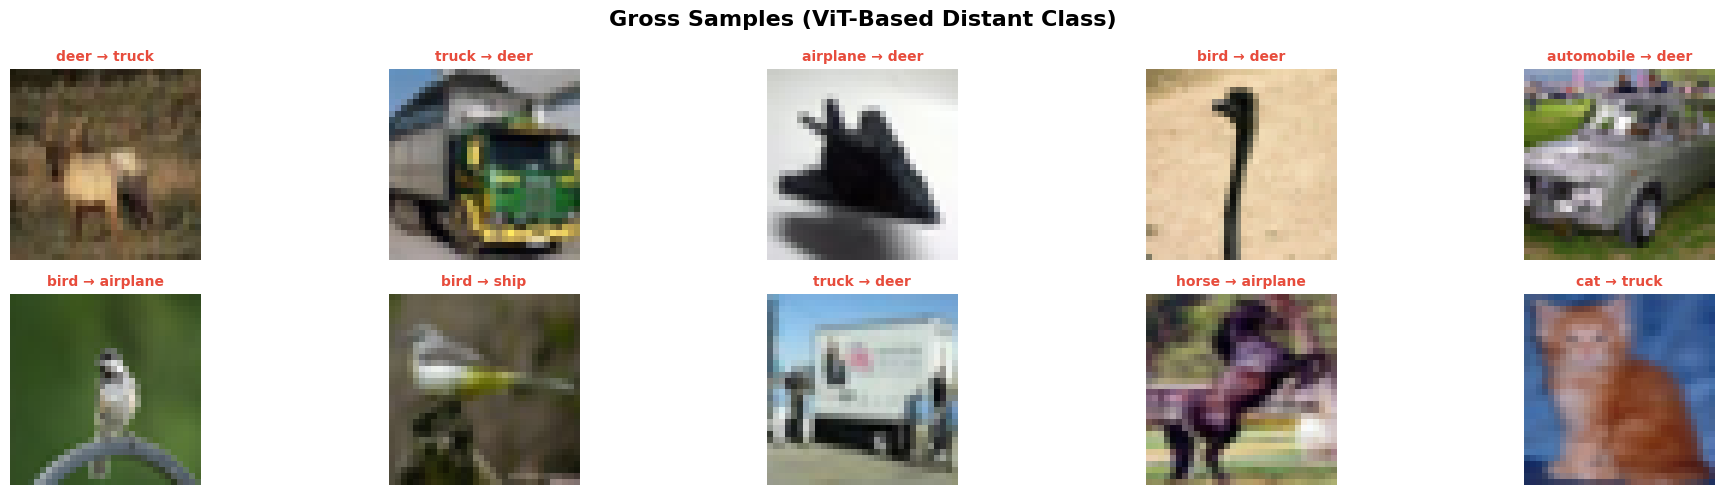

Saved: gross_samples.png


In [9]:
def plot_gross_samples(df, imgs, n=10):
    gr = df[df['anomaly_type']=='gross'].head(n)
    fig, axes = plt.subplots(2, n//2, figsize=(20, 5))
    fig.suptitle('Gross Samples (ViT-Based Distant Class)', fontsize=16, fontweight='bold')
    
    for i, (_, s) in enumerate(gr.iterrows()):
        ax = axes[i//5, i%5]
        ax.imshow(imgs[s['sample_index']])
        ax.axis('off')
        ax.set_title(f"{s['original_class_name']} → {s['synthetic_class_name']}", fontsize=10, fontweight='bold', color='#e74c3c')
        for sp in ax.spines.values(): sp.set_edgecolor('#e74c3c'); sp.set_linewidth(2.5)
    
    plt.tight_layout()
    path = OUTPUT_DIR/'gross_samples.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path.name}')

plot_gross_samples(df10, cifar10_viz, n=10)

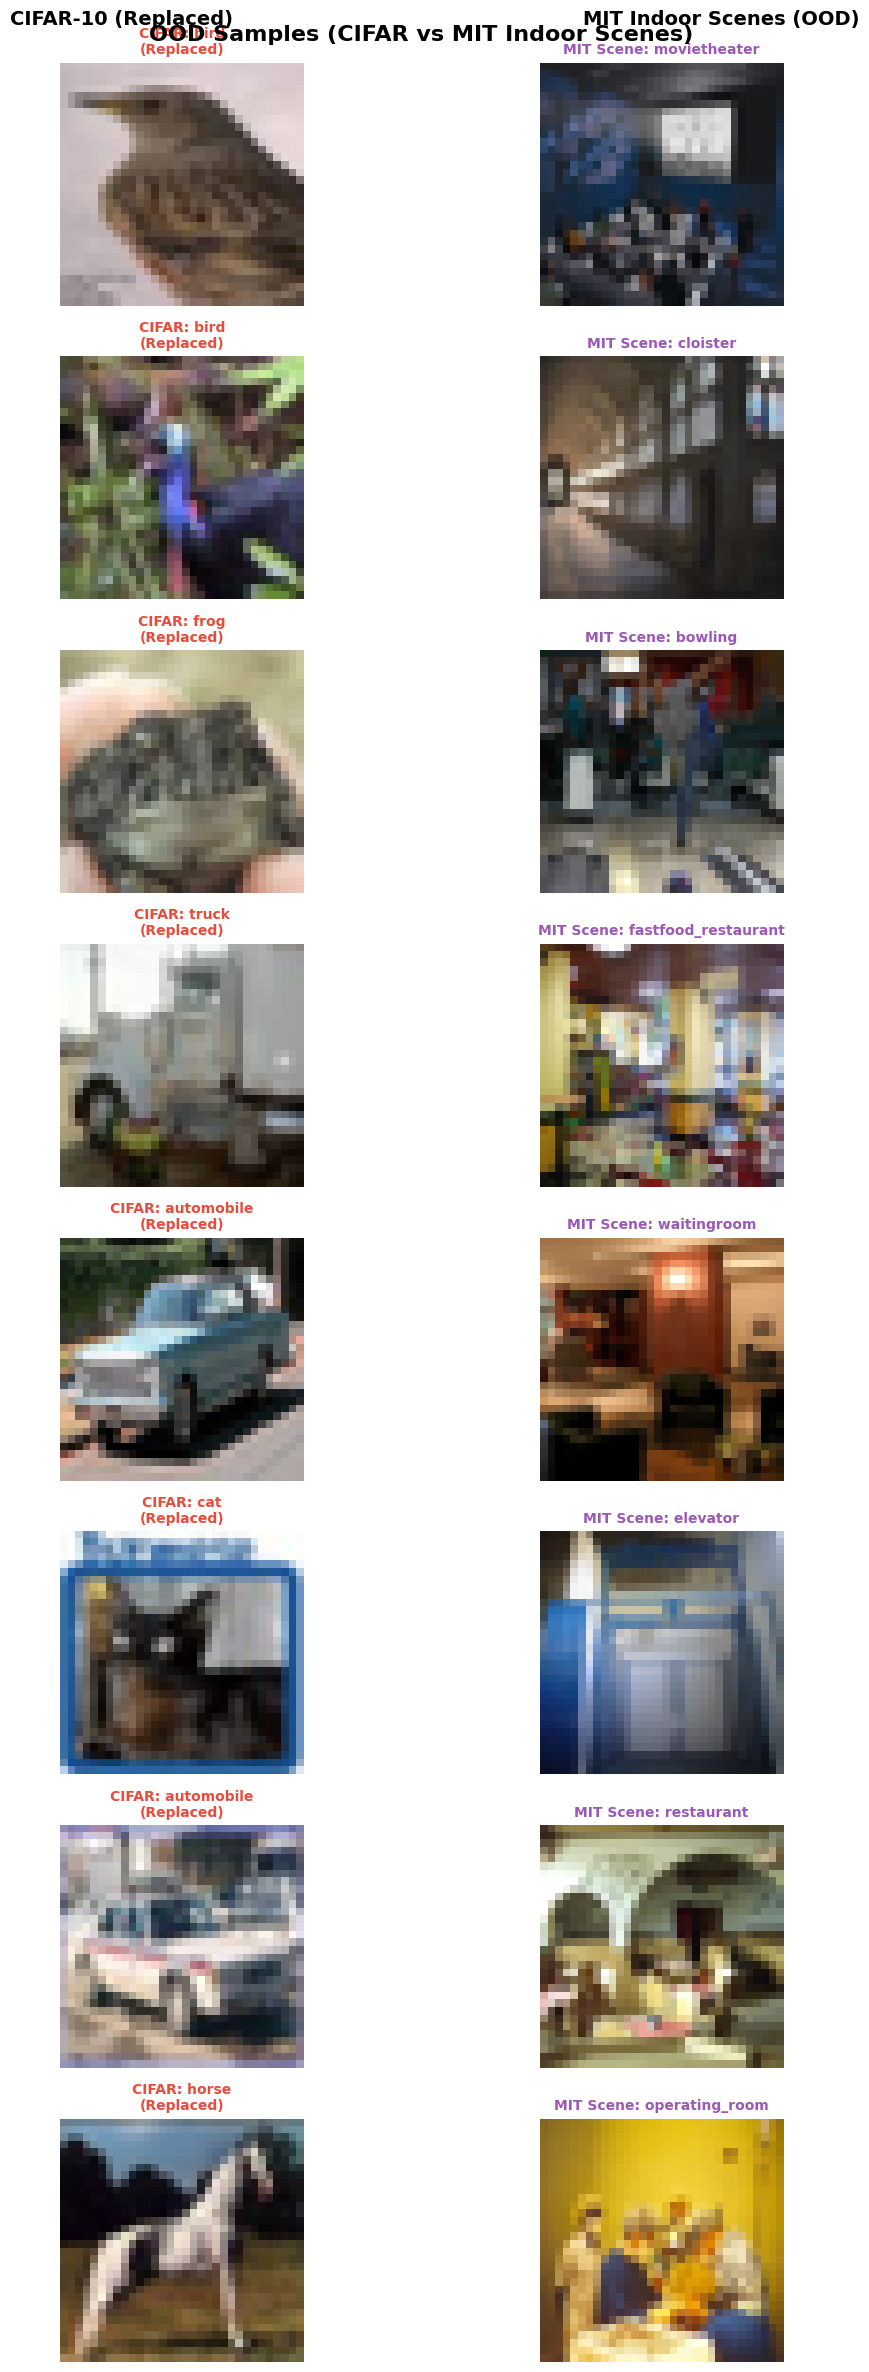

Saved: ood_samples.png


In [10]:
def plot_ood_samples(df, imgs, mit_scenes, n=8):
    ood = df[df['anomaly_type']=='ood'].head(n)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3*n))
    fig.suptitle('OOD Samples (CIFAR vs MIT Indoor Scenes)', fontsize=16, fontweight='bold')
    
    for i, (_, s) in enumerate(ood.iterrows()):
        # Left: Original CIFAR
        axes[i,0].imshow(imgs[s['sample_index']])
        axes[i,0].axis('off')
        axes[i,0].set_title(f"CIFAR: {s['original_class_name']}\n(Replaced)", fontsize=10, fontweight='bold', color='#e74c3c')
        
        # Right: MIT Scene
        matching = [m for m in mit_scenes if m[1]==s['ood_category']]
        if matching:
            ood_img = matching[0][0].reshape(3,32,32).transpose(1,2,0)
            axes[i,1].imshow(ood_img)
            axes[i,1].axis('off')
            axes[i,1].set_title(f"MIT Scene: {s['ood_category']}", fontsize=10, fontweight='bold', color='#9b59b6')
    
    fig.text(0.25, 0.98, 'CIFAR-10 (Replaced)', fontsize=14, fontweight='bold', ha='center')
    fig.text(0.75, 0.98, 'MIT Indoor Scenes (OOD)', fontsize=14, fontweight='bold', ha='center')
    plt.tight_layout()
    path = OUTPUT_DIR/'ood_samples.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path.name}')

plot_ood_samples(df10, cifar10_viz, mit_scenes, n=8)

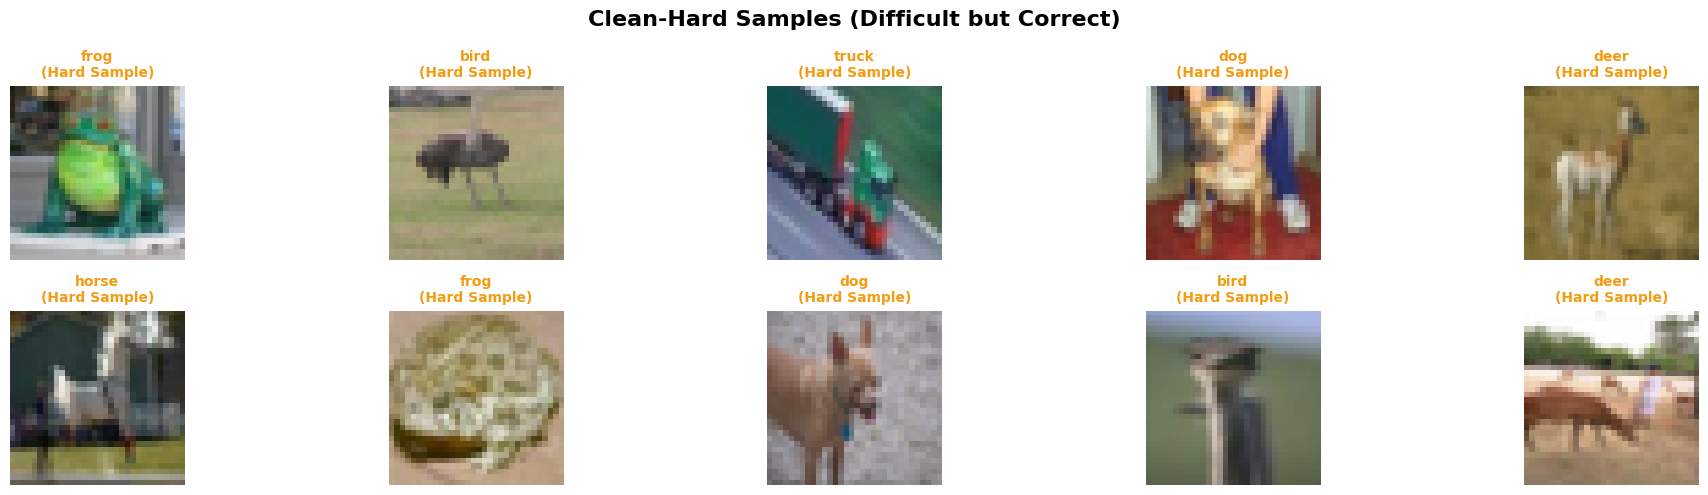

Saved: clean_hard_samples.png


In [11]:
def plot_clean_hard_samples(df, imgs, n=10):
    ch = df[(df['anomaly_type']=='clean_hard') & (df['is_hard_sample']==True)].head(n)
    fig, axes = plt.subplots(2, n//2, figsize=(20, 5))
    fig.suptitle('Clean-Hard Samples (Difficult but Correct)', fontsize=16, fontweight='bold')
    
    for i, (_, s) in enumerate(ch.iterrows()):
        ax = axes[i//5, i%5]
        ax.imshow(imgs[s['sample_index']])
        ax.axis('off')
        ax.set_title(f"{s['original_class_name']}\n(Hard Sample)", fontsize=10, fontweight='bold', color='#f39c12')
        for sp in ax.spines.values(): sp.set_edgecolor('#f39c12'); sp.set_linewidth(2.5)
    
    plt.tight_layout()
    path = OUTPUT_DIR/'clean_hard_samples.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path.name}')

plot_clean_hard_samples(df10, cifar10_viz, n=10)

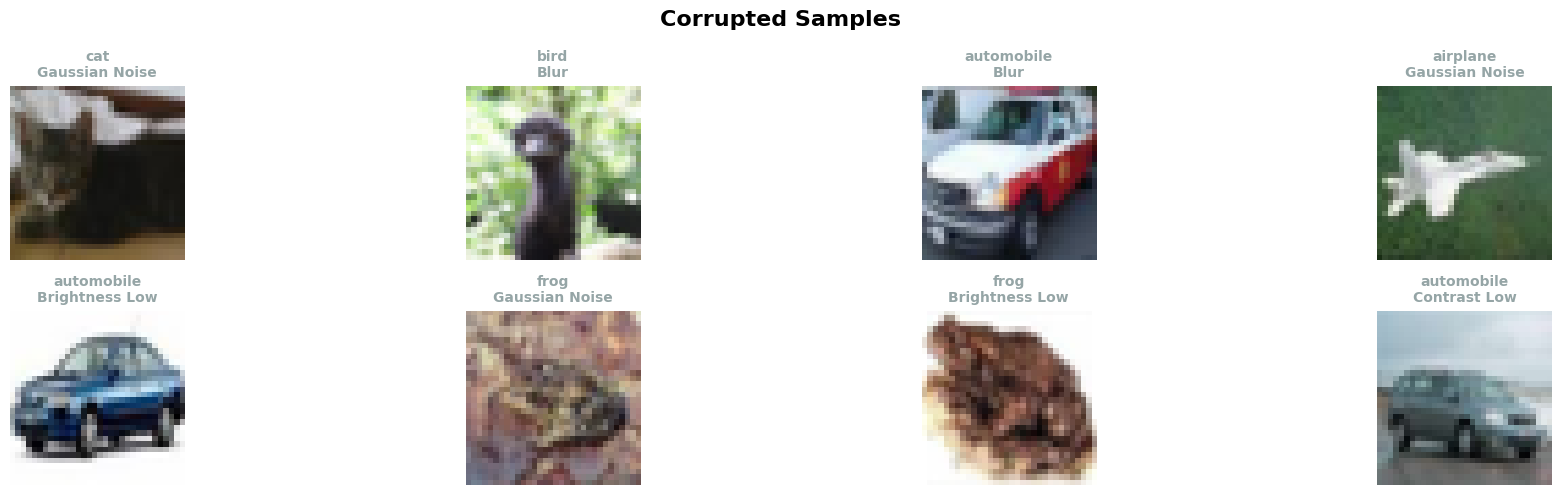

Saved: corrupted_samples.png


In [12]:
def plot_corrupted_samples(df, imgs, n=8):
    corr = df[df['anomaly_type']=='corrupted'].head(n)
    fig, axes = plt.subplots(2, n//2, figsize=(20, 5))
    fig.suptitle('Corrupted Samples', fontsize=16, fontweight='bold')
    
    for i, (_, s) in enumerate(corr.iterrows()):
        ax = axes[i//4, i%4]
        ax.imshow(imgs[s['sample_index']])
        ax.axis('off')
        ct = s['corruption_type'].replace('_',' ').title()
        ax.set_title(f"{s['original_class_name']}\n{ct}", fontsize=10, fontweight='bold', color='#95a5a6')
        for sp in ax.spines.values(): sp.set_edgecolor('#95a5a6'); sp.set_linewidth(2.5)
    
    plt.tight_layout()
    path = OUTPUT_DIR/'corrupted_samples.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path.name}')

plot_corrupted_samples(df10, cifar10_viz, n=8)

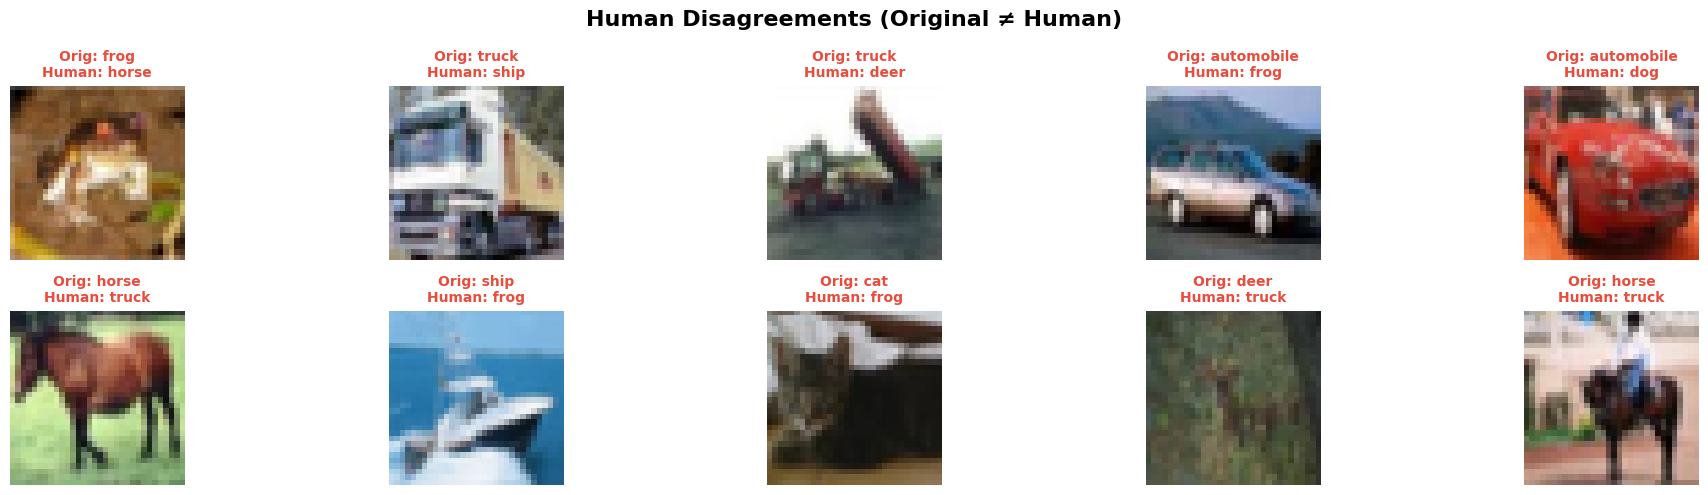

Saved: human_disagreements.png


In [13]:
def plot_human_disagreements(df, imgs, n=10):
    human_df = df[(df['human_label_available']) & (df['human_label']!='')]
    disagreements = human_df[human_df['original_label']!=human_df['human_label']].head(n)
    
    if len(disagreements)==0:
        print('No disagreements found!')
        return
    
    fig, axes = plt.subplots(2, n//2, figsize=(20, 5))
    fig.suptitle('Human Disagreements (Original ≠ Human)', fontsize=16, fontweight='bold')
    
    for i, (_, s) in enumerate(disagreements.iterrows()):
        ax = axes[i//5, i%5]
        ax.imshow(imgs[s['sample_index']])
        ax.axis('off')
        ax.set_title(f"Orig: {s['original_class_name']}\nHuman: {s['human_class_name']}", fontsize=10, fontweight='bold', color='#e74c3c')
        for sp in ax.spines.values(): sp.set_edgecolor('#e74c3c'); sp.set_linewidth(2.5)
    
    plt.tight_layout()
    path = OUTPUT_DIR/'human_disagreements.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path.name}')

plot_human_disagreements(df10, cifar10_viz, n=10)

In [14]:
def save_csv(rows, path):
    with open(path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader(); w.writerows(rows)
    print(f'Saved: {path}')

save_csv(cifar10_rows, OUTPUT_DIR/"cifar10_synthetic_noisy_metadata_vit.csv")
save_csv(cifar100_rows, OUTPUT_DIR/"cifar100_synthetic_noisy_metadata_vit.csv")

meta = {
    'cifar10_classes': CIFAR10_CLASSES, 'cifar100_classes': CIFAR100_CLASSES,
    'vit_model': VIT_MODEL_NAME, 'feature_dim': FEATURE_DIM, 'random_seed': RANDOM_SEED,
    'anomaly_ratios': ANOMALY_RATIOS, 'corruption_types': CORRUPTION_TYPES,
    'mit_scenes_categories': list(set(c for _,c in mit_scenes)),
    'uses_vit_features': True
}
with open(OUTPUT_DIR/"dataset_metadata_vit.json", 'w') as f: json.dump(meta, f, indent=2)
print(f'Saved: dataset_metadata_vit.json')

Saved: /projectnb/ivc-ml/appledora/CS506/cs506-anomaly-det/data_vit_base/cifar10_synthetic_noisy_metadata_vit.csv
Saved: /projectnb/ivc-ml/appledora/CS506/cs506-anomaly-det/data_vit_base/cifar100_synthetic_noisy_metadata_vit.csv
Saved: dataset_metadata_vit.json


In [15]:
def print_summary(rows, name):
    print(f"\n{'='*70}\n{name.upper()} SUMMARY\n{'='*70}")
    print(f"Total: {len(rows):,}")
    print(f"\nDistribution:")
    ac = Counter(r['anomaly_type'] for r in rows)
    em = {'clean':'🟢','near_miss':'🔵','gross':'🔴','ood':'🟣','clean_hard':'🟠','random_flip':'🔷','ambiguous':'⚪','corrupted':'🔸'}
    for at in ['clean','near_miss','gross','ood','clean_hard','random_flip','ambiguous','corrupted']:
        c = ac.get(at,0)
        print(f"  {em.get(at,'⚪')} {at.replace('_',' ').title():12s}: {c:5,} ({c/len(rows)*100:5.1f}%)")
    
    hr = [r for r in rows if r['human_label_available'] and r['human_label']!='']
    if hr:
        om = sum(1 for r in hr if r['original_label']==r['human_label'])
        sm = sum(1 for r in hr if r['synthetic_label']==r['human_label'])
        print(f"\nHuman Agreement: Orig={om/len(hr)*100:.2f}%, Synth={sm/len(hr)*100:.2f}%")

print_summary(cifar10_rows, 'CIFAR-10')
print_summary(cifar100_rows, 'CIFAR-100')

print(f"\nOutput: {OUTPUT_DIR}")
viz = list(OUTPUT_DIR.glob("*.png"))
print(f"Visualizations: {len(viz)} files")


CIFAR-10 SUMMARY
Total: 50,000

Distribution:
  🟢 Clean       : 17,500 ( 35.0%)
  🔵 Near Miss   : 7,500 ( 15.0%)
  🔴 Gross       : 5,000 ( 10.0%)
  🟣 Ood         : 2,500 (  5.0%)
  🟠 Clean Hard  : 7,500 ( 15.0%)
  🔷 Random Flip : 5,000 ( 10.0%)
  ⚪ Ambiguous   : 2,500 (  5.0%)
  🔸 Corrupted   : 2,500 (  5.0%)

Human Agreement: Orig=9.79%, Synth=14.00%

CIFAR-100 SUMMARY
Total: 50,000

Distribution:
  🟢 Clean       : 17,500 ( 35.0%)
  🔵 Near Miss   : 7,500 ( 15.0%)
  🔴 Gross       : 5,000 ( 10.0%)
  🟣 Ood         : 2,500 (  5.0%)
  🟠 Clean Hard  : 7,500 ( 15.0%)
  🔷 Random Flip : 5,000 ( 10.0%)
  ⚪ Ambiguous   : 2,500 (  5.0%)
  🔸 Corrupted   : 2,500 (  5.0%)

Human Agreement: Orig=0.98%, Synth=5.85%

Output: /projectnb/ivc-ml/appledora/CS506/cs506-anomaly-det/data_vit_base
Visualizations: 8 files
